# Human Pose Image Classification Using Vision Transformer(VIT)

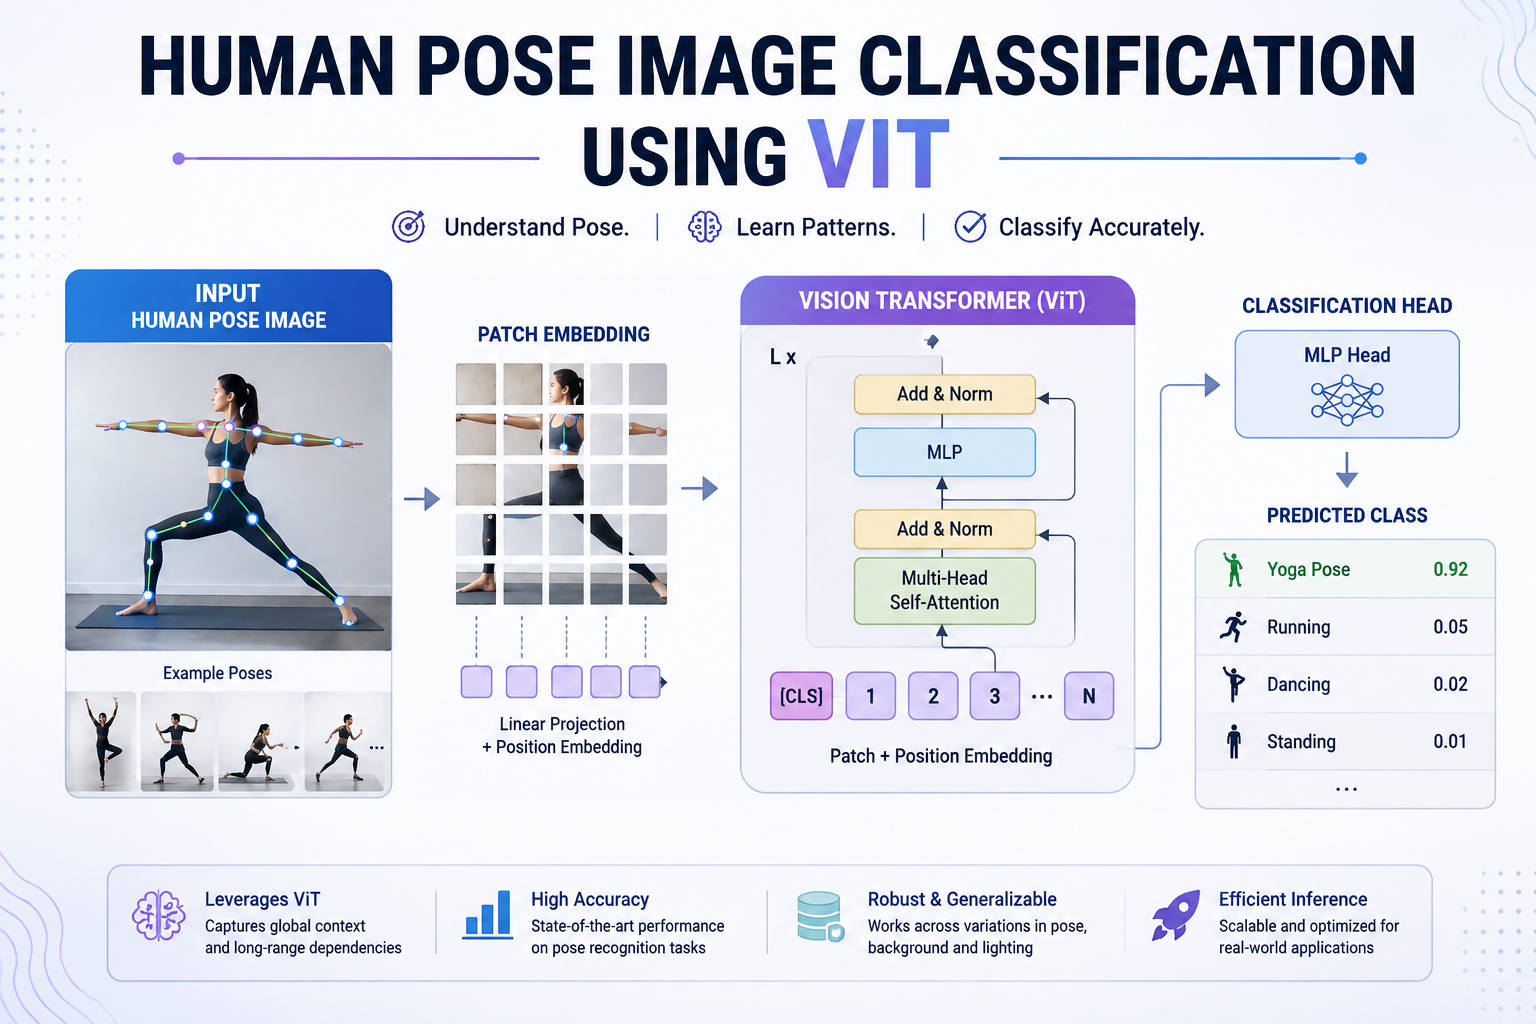

# Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
dataset = load_dataset("Bingsu/Human_Action_Recognition", split = 'train')

In [2]:
dataset = dataset.shuffle().train_test_split(test_size=0.2)

dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 10080
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 2520
    })
})

In [3]:
dataset['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=126x84>,
 'labels': 9}

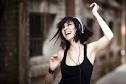

In [4]:
dataset['train'][0]['image']

In [5]:
labels = dataset['train'].features['labels'].names

label2id, id2label = dict(), dict()

for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

print(label2id)
print(id2label)


{'calling': 0, 'clapping': 1, 'cycling': 2, 'dancing': 3, 'drinking': 4, 'eating': 5, 'fighting': 6, 'hugging': 7, 'laughing': 8, 'listening_to_music': 9, 'running': 10, 'sitting': 11, 'sleeping': 12, 'texting': 13, 'using_laptop': 14}
{0: 'calling', 1: 'clapping', 2: 'cycling', 3: 'dancing', 4: 'drinking', 5: 'eating', 6: 'fighting', 7: 'hugging', 8: 'laughing', 9: 'listening_to_music', 10: 'running', 11: 'sitting', 12: 'sleeping', 13: 'texting', 14: 'using_laptop'}


# Image Preprocessing

In [15]:
from transformers import AutoImageProcessor   # --> like tokenizer

model_ckpt = "google/vit-base-patch16-224-in21k"

In [12]:
# !pip install torchvision

In [19]:
from torchvision.transforms import RandomResizedCrop, Compose, Normalize, ToTensor

image_processor = AutoImageProcessor.from_pretrained(model_ckpt, use_fast = True)

normalize = Normalize(mean = image_processor.image_mean, std=image_processor.image_std)

size = (image_processor.size['shortest_edge'] if 'shortest_edge' in image_processor.size else (image_processor.size['height'], image_processor.size['width']))

_transform = Compose([RandomResizedCrop(size), ToTensor(), normalize])

def transforms(batch):
    batch['pixel_values'] = [_transform(img.convert('RGB')) for img in batch['image']]

    del batch['image']
    return batch

In [20]:
dataset = dataset.with_transform(transforms)

# Model Evaluation

In [22]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Vision Transformer (VIT) Fine Tuning For Image Classification

In [23]:
model_ckpt

'google/vit-base-patch16-224-in21k'

In [24]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
import torch

In [25]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [26]:
model = AutoModelForImageClassification.from_pretrained(
    model_ckpt,
    num_labels = len(labels),
    id2label =id2label,
    label2id = label2id
).to(device)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Model Training